# **Convolutional Neural Networks**
Realizado por: Ignacia Reyes Espinoza. 

# Indice:


1.   Introducción y objetivo del trabajo.
2.   Carga de librerías y dataset.
3.   Exploración inicial de datos.
4.   Preprocesamiento.
5.   Modelo CNN base.
6.   Entrenamiento y evaluación del modelo base.
7.   Búsqueda del mejor modelo base.
8.   Construcción y evaluación del mejor modelo base.
9.   Regularización y mejora del mejor modelo base.
10.  Comparación entre modelo base y modelo final.
11.  Evaluación final en el conjunto de prueba.
12.  Visualización de predicciones del modelo final.
13.  Conclusión.
---

# **1. Introducción y objetivo del trabajo.**

### **Clasificación de personajes de Los Simpsons mediante Redes Neuronales Convolucionales.**

En este trabajo se desarrolla un modelo de Deep Learning basado en Redes Neuronales Convolucionales, o CNN, para clasificar imágenes de personajes de la serie *Los Simpsons*. El dataset utilizado contiene imágenes organizadas por clases, donde cada clase representa un personaje distinto.

Las CNN son especialmente adecuadas para problemas de clasificación de imágenes, ya que permiten extraer características visuales como bordes, colores, formas, texturas y patrones espaciales. A diferencia de una red neuronal tradicional, una CNN conserva la estructura espacial de la imagen y utiliza capas convolucionales para aprender representaciones visuales de forma progresiva.

El desarrollo del proyecto se realizó mediante un proceso experimental. Primero, se cargaron y preprocesaron las imágenes, normalizando sus valores y separando los datos en entrenamiento, validación y prueba. Luego, se probaron distintas configuraciones para construir un mejor modelo base, evaluando cambios en la profundidad de la arquitectura, funciones de activación, optimizadores y función de pérdida.

Una vez definido el mejor modelo base, se analizó su comportamiento y se identificaron señales de sobreajuste. Por esta razón, se aplicaron técnicas como Dropout, Batch Normalization y Data Augmentation, con el objetivo de mejorar la generalización del modelo frente a imágenes no vistas.

Finalmente, el modelo seleccionado fue evaluado mediante métricas como accuracy, precision, recall y F1-score, además de una matriz de confusión y visualizaciones de predicciones. Esto permitió analizar tanto el rendimiento general del modelo como sus aciertos y errores por clase.

### Objetivo general

Implementar, comparar y evaluar modelos de Redes Neuronales Convolucionales para clasificar imágenes de personajes de *Los Simpsons*, seleccionando una arquitectura final que logre un buen rendimiento y una adecuada capacidad de generalización.

### Objetivos específicos

- Cargar y explorar el dataset de imágenes de personajes de *Los Simpsons*.
- Preprocesar las imágenes para ser utilizadas en modelos CNN.
- Construir un modelo CNN base y analizar su comportamiento inicial.
- Comparar distintas configuraciones de arquitectura e hiperparámetros, incluyendo profundidad de la red, funciones de activación, optimizadores y función de pérdida.
- Identificar señales de sobreajuste mediante curvas de accuracy y loss.
- Aplicar técnicas de regularización y mejora de generalización, como Dropout, Batch Normalization y Data Augmentation.
- Seleccionar el modelo final a partir de métricas de validación y comparación con el modelo base.
- Evaluar el modelo final sobre el conjunto de prueba mediante accuracy, precision, recall, F1-score, matriz de confusión y análisis visual de predicciones.

---
---

# **2 Carga de los datos:**

In [103]:
# Importación de librerias necesarias:

from google.colab.patches import cv2_imshow
from IPython.display import clear_output
from tensorflow.keras.callbacks import Callback

import os
import glob
import random
import collections
import itertools

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model
from keras.models import Sequential
from tensorflow.keras import layers
from keras.layers import Dense, Activation , Dropout, Flatten, BatchNormalization, MaxPooling2D, Conv2D
from keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator


from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tabulate import tabulate

%matplotlib inline

In [14]:
# Fijamos semillas para reducir variaciones entre ejecuciones:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [15]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a estandarizar todas las imágenes a tamaño 64x64:
IMG_SIZE = 64

In [16]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintos, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [17]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)

Función para el progeso de las épocas:

In [39]:
class ProgresoEpocas(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        total_epochs = self.params["epochs"]
        progreso = ((epoch + 1) / total_epochs) * 100

        clear_output(wait=True)

        print(f"Progreso del entrenamiento: {epoch + 1}/{total_epochs} épocas ({progreso:.1f}%)")
        print(f"Accuracy: {logs.get('accuracy', 0):.4f}")
        print(f"Val Accuracy: {logs.get('val_accuracy', 0):.4f}")
        print(f"Loss: {logs.get('loss', 0):.4f}")
        print(f"Val Loss: {logs.get('val_loss', 0):.4f}")

### Cargar archivos desde Google Drive:

Se realiza una copia a las carpetas para que estas puedan ser leídas de manera rápida.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Copia de ambas carpetas:
!mkdir -p /content/datasets_simpsons

!cp -r "/content/drive/MyDrive/DEEPLEARNING/simpsons" /content/datasets_simpsons/
!cp -r "/content/drive/MyDrive/DEEPLEARNING/simpsons_testset" /content/datasets_simpsons/

In [20]:
# Carga de los datos:
DATASET_TRAIN_PATH_COLAB = "/content/datasets_simpsons/simpsons"
DATASET_TEST_PATH_COLAB = "/content/datasets_simpsons/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


In [21]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
#==================================================================#
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

---
---

# **3. Exploración inicial de datos.**

Una vez cargadas las imágenes, se revisan las dimensiones de los conjuntos de entrenamiento y prueba. Esto permite verificar que las imágenes fueron leídas correctamente y que las etiquetas corresponden a las clases definidas en el problema.

Además, se analiza la cantidad de imágenes por clase, ya que un desbalance fuerte entre personajes puede afectar el rendimiento del modelo durante el entrenamiento.

In [22]:
# Revisamos las dimensiones de los datos cargados:
print("X train:", X.shape)
print("y train:", y.shape)

print("X test:", X_t.shape)
print("y test:", y_t.shape)

print("Tipo de dato de X:", X.dtype)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())

X train: (18992, 64, 64, 3)
y train: (18992,)
X test: (890, 64, 64, 3)
y test: (890,)
Tipo de dato de X: uint8
Valor mínimo: 0
Valor máximo: 255


Cada imagen pertenece a una de las clases disponibles, donde cada clase representa un personaje de Los Simpsons. Las etiquetas numéricas son utilizadas por el modelo, mientras que los nombres de personajes se utilizan para interpretar los resultados.

In [23]:
# Lista de nombres de clases ordenada por etiqueta:
class_names = [MAP_CHARACTERS[i] for i in range(len(MAP_CHARACTERS))]

print("Cantidad de clases:", len(class_names))
print(class_names)

Cantidad de clases: 18
['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lisa_simpson', 'marge_simpson', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'principal_skinner', 'sideshow_bob']


## 3.1 Distribución de imágenes por clase:

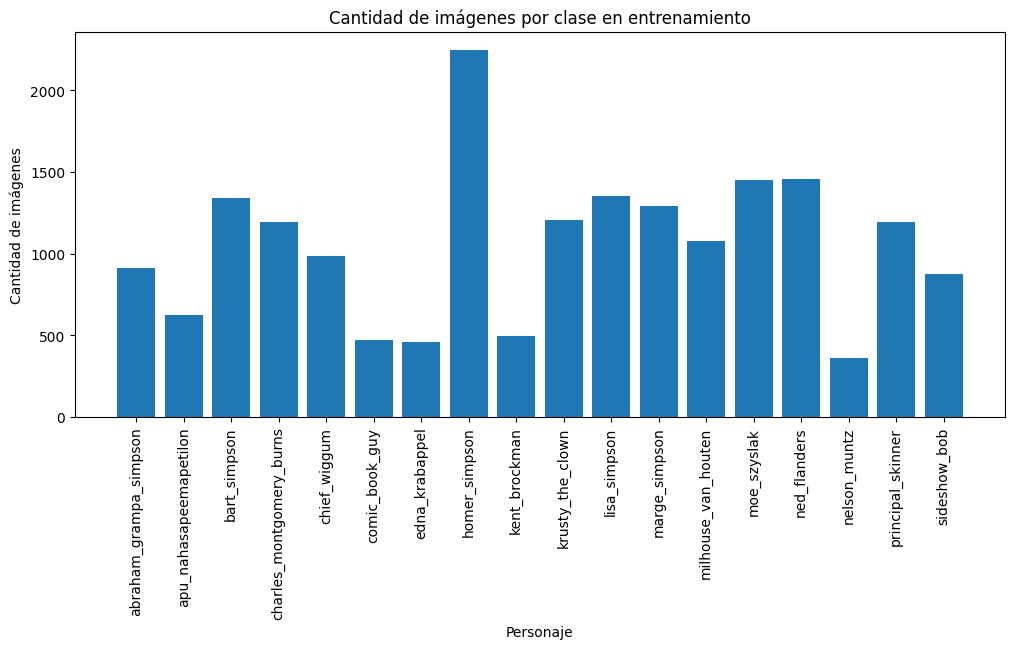

In [24]:
# Distribución de clases en entrenamiento:
conteo_train = pd.Series(y).value_counts().sort_index()

# Distribución gráfica:
plt.figure(figsize=(12,5))
plt.bar(class_names, conteo_train.values)
plt.xticks(rotation=90)
plt.title("Cantidad de imágenes por clase en entrenamiento")
plt.xlabel("Personaje")
plt.ylabel("Cantidad de imágenes")
plt.show()

El gráfico muestra la cantidad de imágenes disponibles por personaje en el conjunto de entrenamiento. Esta revisión es importante porque si algunas clases tienen muchas más imágenes que otras, el modelo podría aprender mejor esas clases y presentar más errores en personajes con menos ejemplos.

## 3.2 Visualizar imágenes del dataset:

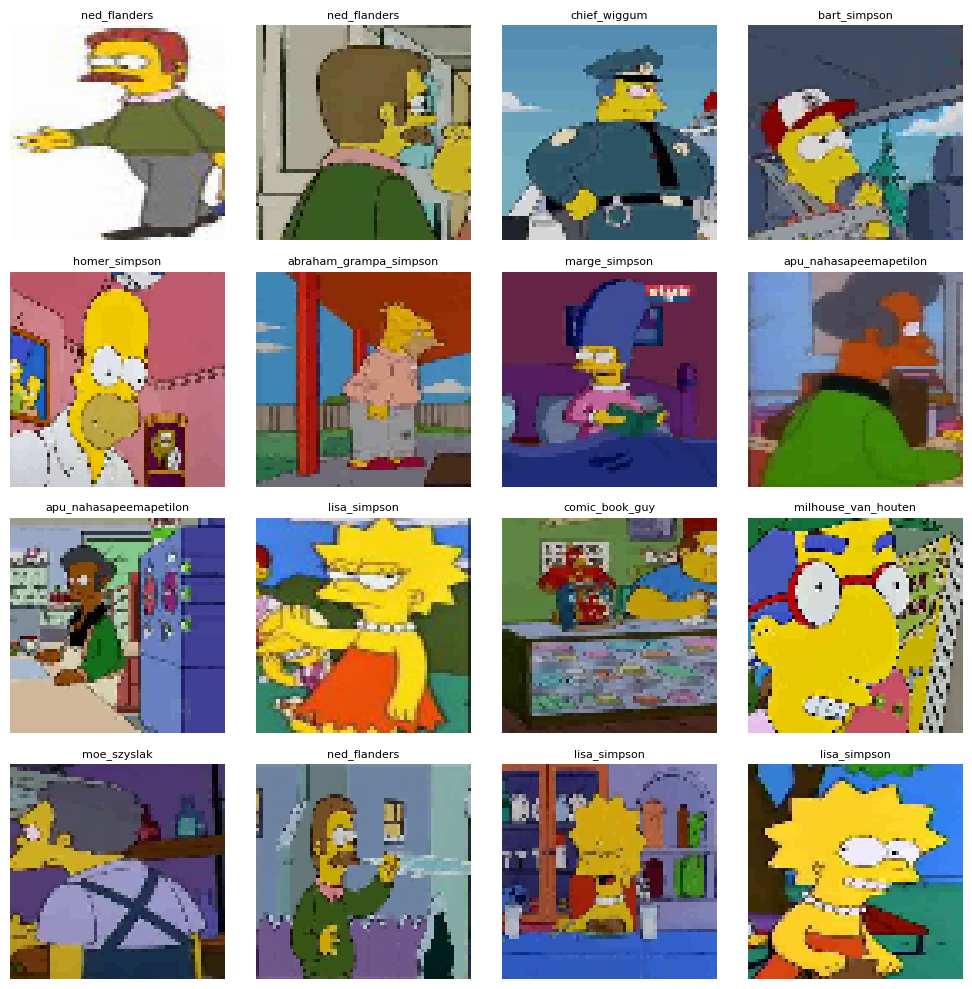

In [25]:
# Visualización de ejemplos aleatorios del dataset:

plt.figure(figsize=(10,10))

for i in range(16):
    idx = np.random.randint(0, len(X))
    img = cv2.cvtColor(X[idx], cv2.COLOR_BGR2RGB)

    plt.subplot(4,4,i+1)
    plt.imshow(img)
    plt.title(class_names[y[idx]], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

Se visualizaron imágenes aleatorias del dataset para comprobar que la carga fue correcta. Esta etapa permite observar la variabilidad visual de los personajes, diferencias de color, postura, fondo y calidad de imagen.



---



---



# **4. Preprocesamiento.**

Para preparar las imágenes para la CNN, se normalizan los valores de los píxeles dividiéndolos por 255. Esto transforma los valores desde el rango original 0–255 hacia un rango entre 0 y 1, facilitando el entrenamiento del modelo.

A diferencia de una red MLP, en una CNN no se aplanan las imágenes, ya que las capas convolucionales aprovechan la estructura espacial de la imagen, es decir, alto, ancho y canales de color.

## 4.1 Normalización de las imágenes:

In [26]:
# Normalización de imágenes:
X = X.astype("float32") / 255.0
X_t = X_t.astype("float32") / 255.0

# Etiquetas como enteros:
y = y.astype("int32")
y_t = y_t.astype("int32")

print("X train normalizado:", X.shape, X.min(), X.max())
print("X test normalizado:", X_t.shape, X_t.min(), X_t.max())
print("y train:", y.shape)
print("y test:", y_t.shape)

X train normalizado: (18992, 64, 64, 3) 0.0 1.0
X test normalizado: (890, 64, 64, 3) 0.0 1.0
y train: (18992,)
y test: (890,)


## 4.2 Creación de Train y Validation:

El dataset ya incluye un conjunto de entrenamiento y un conjunto de prueba. El conjunto de prueba se mantiene separado para la evaluación final. A partir del conjunto de entrenamiento se separa un subconjunto de validación, utilizado solo para comparar modelos y detectar sobreajuste.

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_test = X_t
y_test = y_t

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (15193, 64, 64, 3)
X_val: (3799, 64, 64, 3)
X_test: (890, 64, 64, 3)
y_train: (15193,)
y_val: (3799,)
y_test: (890,)


El dataset original incluye un conjunto de entrenamiento y un conjunto de prueba. El conjunto de prueba se mantiene separado para la evaluación final.

A partir del conjunto de entrenamiento se separa un subconjunto de validación. Esta validación no reemplaza al test, sino que se utiliza para comparar modelos durante el desarrollo y evitar utilizar el conjunto de prueba antes de la evaluación final.

Se utilizó una división estratificada para mantener una proporción similar de clases en entrenamiento y validación.

Ahora en adelante utilizaremos las siguientes variables para entrenar modelos:
- X_train, y_train
- X_val, y_val
- X_test, y_test



---



---



# **5. Modelo CNN base.**

En esta sección se define una primera arquitectura CNN base para clasificar imágenes de personajes de Los Simpsons.

- La red convolucional se compone de capas `Conv2D`, encargadas de extraer características visuales como bordes, formas y patrones.
- Capas `MaxPooling2D`, que reducen la dimensionalidad de las imágenes manteniendo la información más relevante.
- Capas densas al final, encargadas de realizar la clasificación.

Este modelo se utilizará como punto de comparación inicial para luego aplicar mejoras en la arquitectura e hiperparámetros.

## 5.1 Definición de variables principales:

In [29]:
# Definimos variables principales para el modelo CNN:
IMG_HEIGHT = X_train.shape[1]
IMG_WIDTH = X_train.shape[2]
IMG_CHANNELS = X_train.shape[3]

NUM_CLASSES = len(class_names)

input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

print("Tamaño de entrada:", input_shape)
print("Cantidad de clases:", NUM_CLASSES)

Tamaño de entrada: (64, 64, 3)
Cantidad de clases: 18


## 5.2 Creación del modelo CNN base:

In [30]:
def crear_modelo_cnn_base():
    model = keras.Sequential([
        # Capa de entrada:
        keras.Input(shape=input_shape),

        # Primer bloque convolucional: 32 filtros.
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Segundo bloque convolucional: 64 filtros.
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Tercer bloque convolucional: 128 filtros.
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Conversión de mapas de características a vector:
        layers.Flatten(),

        # Capa densa para clasificación:
        layers.Dense(128, activation='relu'),

        # Capa de salida:
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## 5.3 Visualización de la arquitectura:

In [31]:
model_base = crear_modelo_cnn_base()
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,522 (2.62 MB)

 Trainable params: 685,522 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

### Arquitectura base:

La arquitectura CNN base utiliza tres bloques convolucionales. Cada bloque está compuesto por una capa `Conv2D` y una capa `MaxPooling2D`.

La primera capa convolucional utiliza 32 filtros, la segunda 64 filtros y la tercera 128 filtros. Esta progresión permite que el modelo aprenda características cada vez más complejas: primero patrones simples como bordes y colores, y luego formas más específicas asociadas a los personajes.

La función de activación utilizada en las capas ocultas es ReLU, ya que permite un entrenamiento eficiente y ayuda a capturar relaciones no lineales en las imágenes.

Las capas `MaxPooling2D` reducen el tamaño espacial de las representaciones, disminuyendo la cantidad de parámetros y el costo computacional.

Luego, la capa `Flatten` transforma los mapas de características en un vector, el cual es procesado por una capa densa de 128 neuronas.

Se utiliza `sparse_categorical_crossentropy` porque las etiquetas se encuentran representadas como valores enteros.
Este modelo base permitirá establecer un primer rendimiento de referencia para luego comparar mejoras en la arquitectura.

Finalmente, la capa de salida utiliza `softmax`, ya que el problema corresponde a una clasificación multiclase. Esta función entrega una probabilidad para cada personaje.

### **Hiperparámetros del modelo base**

Para el modelo base se utilizaron los siguientes hiperparámetros:

| Parámetros | Valores |
| :--- | :---: |
| Epoch| 50 |
| Batch size | 64 |
| Filtros convolucionnales | 32, 64 y 128 |
| Tamaño de kernel | 3x3 |
| Modelo | Base Profunda con Padding |
| Función de Activación | ReLU |
| Optimizador | Adam  |
| Learning rate | 0.001 |
| Función de Pérdida | sparse_categorical_crossentropy |
| Métrica principal | accuracy

---
---

# **6. Entrenamiento y evaluación del modelo base.**

En esta sección se entrena la arquitectura CNN base definida anteriormente. Este modelo servirá como punto de referencia para comparar futuras mejoras en la arquitectura e hiperparámetros.

Se utilizará un número inicial de épocas y un tamaño de batch estándar, permitiendo observar el comportamiento del modelo en términos de accuracy y loss tanto en entrenamiento como en validación.

## 6.1 Entrenamiento del modelo CNN base:

In [40]:
# Entrenamiento del modelo CNN base:
history_base = model_base.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=0,
    callbacks=[ProgresoEpocas()]
)

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9997
Val Accuracy: 0.8563
Loss: 0.0004
Val Loss: 1.4287


## 6.2 Gráfico de los resultados:

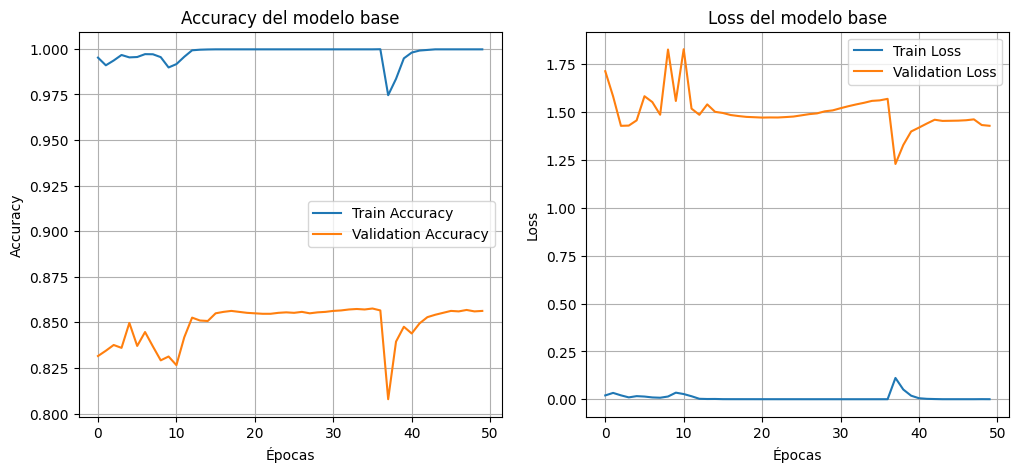

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy del modelo base')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('Loss del modelo base')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Se guardarn los resultados del entrenamiento del modelo base en las siguientes variables:
- base_train_acc
- base_val_acc
- base_train_loss
- base_val_loss

In [42]:
base_train_acc = history_base.history['accuracy'][-1]
base_val_acc = history_base.history['val_accuracy'][-1]
base_train_loss = history_base.history['loss'][-1]
base_val_loss = history_base.history['val_loss'][-1]

print(f"Train accuracy modelo base: {base_train_acc * 100:.2f}%")
print(f"Val accuracy modelo base: {base_val_acc * 100:.2f}%")
print(f"Train loss modelo base: {base_train_loss:.4f}")
print(f"Val loss modelo base: {base_val_loss:.4f}")

Train accuracy modelo base: 99.97%
Val accuracy modelo base: 85.63%
Train loss modelo base: 0.0004
Val loss modelo base: 1.4287


In [43]:
# Creamos la estructura de datos en filas:
datos = [
    ["Precisión (Accuracy)", f"{base_train_acc * 100:.2f}%", f"{base_val_acc * 100:.2f}%"],
    ["Pérdida (Loss)", f"{base_train_loss:.4f}", f"{base_val_loss:.4f}"]
]

# Definimos los encabezados:
columnas = ["Métrica", "Entrenamiento (Train)", "Validación (Val)"]

# Imprimimos la tabla formateada en la consola:
print("\n RESULTADOS DEL MODELO BASE")
print(tabulate(datos, headers=columnas, tablefmt="fancy_grid", stralign="center"))


 RESULTADOS DEL MODELO BASE
╒══════════════════════╤═════════════════════════╤════════════════════╕
│       Métrica        │  Entrenamiento (Train)  │  Validación (Val)  │
╞══════════════════════╪═════════════════════════╪════════════════════╡
│ Precisión (Accuracy) │         99.97%          │       85.63%       │
├──────────────────────┼─────────────────────────┼────────────────────┤
│    Pérdida (Loss)    │         0.0004          │       1.4287       │
╘══════════════════════╧═════════════════════════╧════════════════════╛


## 6.3 Análisis del modelo CNN base:

El modelo CNN base obtuvo un accuracy de entrenamiento de 0.9999, equivalente a un 99.99%, mientras que el accuracy de validación alcanzó 0.8526, equivalente a un 85.26%.

A primera vista, el modelo parece tener un rendimiento muy alto, ya que logra clasificar casi perfectamente las imágenes del conjunto de entrenamiento. Sin embargo, al comparar este resultado con la validación, se observa una diferencia importante entre ambas métricas.

En el gráfico de accuracy, la línea de entrenamiento aumenta rápidamente hasta acercarse al 100%, mientras que la línea de validación se estabiliza alrededor del 80%–85%. Esto indica que el modelo aprende muy bien los datos conocidos, pero no logra mantener el mismo rendimiento sobre datos nuevos.

En el gráfico de loss ocurre algo similar. La pérdida de entrenamiento disminuye hasta un valor casi nulo, llegando a 0.0004, mientras que la pérdida de validación aumenta y termina en 1.3393. Esta diferencia evidencia que el modelo está memorizando los datos de entrenamiento en lugar de aprender patrones generales.

Por lo tanto, **el modelo base presenta sobreajuste**. Aunque tiene un buen accuracy de validación, la diferencia entre entrenamiento y validación muestra que es necesario aplicar mejoras como:

- regularización.
- Dropout.
- Batch Normalization.


---
---

# **7. Búsqueda del mejor modelo base.**

Antes de aplicar técnicas de regularización, se realizaron pruebas para encontrar una arquitectura base con buen rendimiento.

El objetivo de esta etapa es mejorar la capacidad predictiva inicial del modelo, probando cambios controlados en la arquitectura y configuración de entrenamiento. Para ello se comparan los siguientes elementos:

- Distintas cantidades de Profundidad/capas.
- Activación.
- Optimizador.
- Justificación de pérdida.

En esta etapa no se busca todavía reducir completamente el sobreajuste, sino identificar una configuración base fuerte.

## 7.1 Funciones auxiliares para comparar modelos:

In [44]:
EPOCHS_EXP = 50
BATCH_SIZE_EXP = 64

resultados_base = []
modelos_base = {}
histories_base_exp = {}

### Función para entrenar modelo:

In [48]:
def entrenar_experimento_base(nombre_modelo, modelo):
    print(f"\nEntrenando experimento: {nombre_modelo}")

    history = modelo.fit(
        X_train, y_train,
        epochs=EPOCHS_EXP,
        batch_size=BATCH_SIZE_EXP,
        validation_data=(X_val, y_val),
        verbose=0,
        callbacks=[ProgresoEpocas()]
    )

    modelos_base[nombre_modelo] = modelo
    histories_base_exp[nombre_modelo] = history

    resultados_base.append({
        "Modelo": nombre_modelo,
        "Train Accuracy": history.history["accuracy"][-1],
        "Val Accuracy": history.history["val_accuracy"][-1],
        "Train Loss": history.history["loss"][-1],
        "Val Loss": history.history["val_loss"][-1]
    })

    return history

### Función para graficar modelo:

In [49]:
def graficar_history(history, titulo):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - {titulo}")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - {titulo}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

## 7.2 Comparación de profundidad/capas:

El primer ajuste consiste en comparar distintas profundidades de red. En una CNN, agregar más capas convolucionales permite que el modelo aprenda características visuales más complejas.

Las primeras capas suelen detectar patrones simples como bordes, colores y líneas. Las capas más profundas pueden aprender características más específicas, como formas del rostro, cabello, ropa o rasgos propios de cada personaje.

El objetivo de esta prueba es analizar si una red más profunda mejora el accuracy de validación respecto a una arquitectura más simple.

In [50]:
def crear_cnn_por_profundidad(nombre="simple"):
    model = keras.Sequential()
    model.add(keras.Input(shape=input_shape))

    if nombre == "simple":
        model.add(layers.Conv2D(32, (3,3), activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

        model.add(layers.Conv2D(64, (3,3), activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

    elif nombre == "media":
        model.add(layers.Conv2D(32, (3,3), padding="same", activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

        model.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

        model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

    elif nombre == "profunda":
        model.add(layers.Conv2D(32, (3,3), padding="same", activation="relu"))
        model.add(layers.Conv2D(32, (3,3), padding="same", activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

        model.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
        model.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

        model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu"))
        model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu"))
        model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### 7.2.1 Modelo con profundidad "simple":

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9997
Val Accuracy: 0.7828
Loss: 0.0005
Val Loss: 2.0720


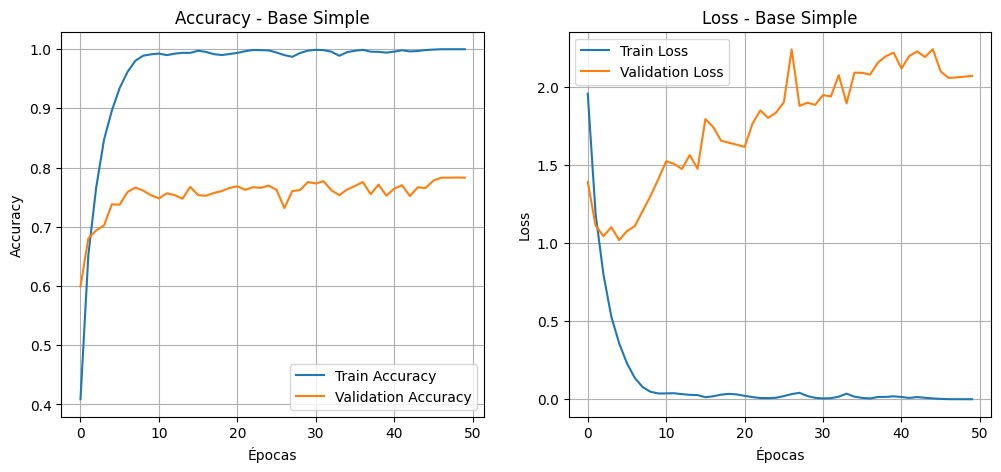

In [51]:
modelo_simple = crear_cnn_por_profundidad("simple")
history_simple = entrenar_experimento_base("Base Simple", modelo_simple)
graficar_history(history_simple, "Base Simple")

### 7.2.2 Modelo con profundidad "media":

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9983
Val Accuracy: 0.8365
Loss: 0.0060
Val Loss: 1.4920


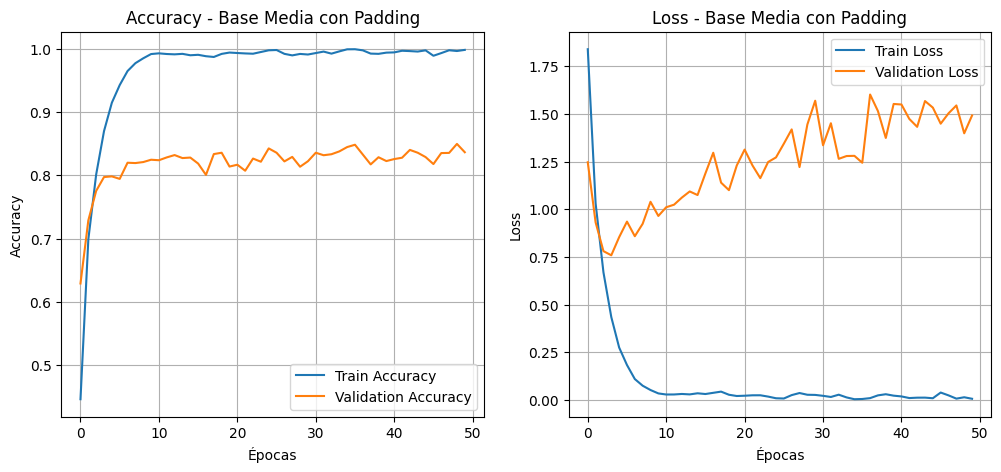

In [52]:
modelo_medio = crear_cnn_por_profundidad("media")
history_medio = entrenar_experimento_base("Base Media con Padding", modelo_medio)
graficar_history(history_medio, "Base Media con Padding")

### 7.2.3 Modelo con profundidad "profunda":

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9997
Val Accuracy: 0.8642
Loss: 0.0009
Val Loss: 1.2354


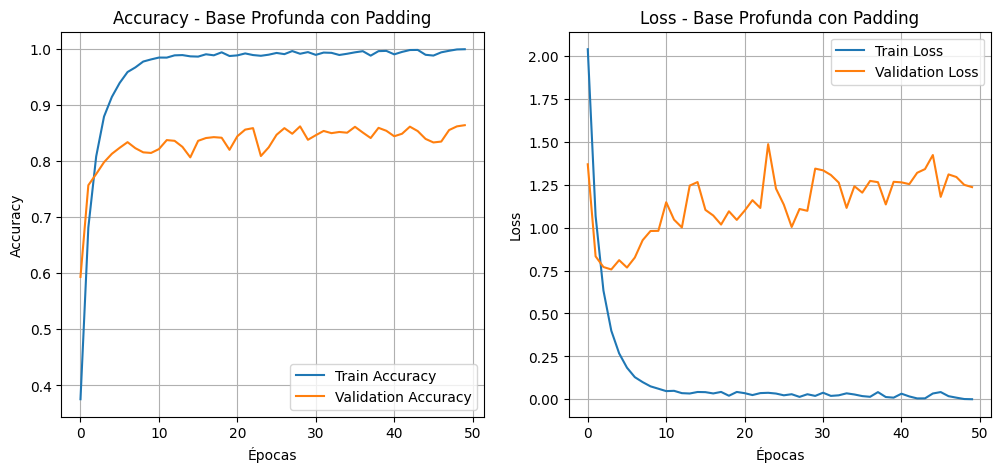

In [53]:
modelo_profundo_base = crear_cnn_por_profundidad("profunda")
history_profundo_base = entrenar_experimento_base("Base Profunda con Padding", modelo_profundo_base)
graficar_history(history_profundo_base, "Base Profunda con Padding")

## 7.3 Comparación de funciones de activación:

Las funciones de activación permiten que la red aprenda relaciones no lineales. Sin ellas, el modelo tendría una capacidad limitada para representar patrones complejos.

Se comparan distintas las siguientes funciones de activación en las capas ocultas:
- ReLU.
- Tanh.
- Elu.

El objetivo es determinar si ReLU sigue siendo la mejor opción para este problema o si otra activación mejora el desempeño.

In [54]:
def crear_cnn_activacion(activacion="relu"):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), padding="same", activation=activacion),
        layers.Conv2D(32, (3,3), padding="same", activation=activacion),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding="same", activation=activacion),
        layers.Conv2D(64, (3,3), padding="same", activation=activacion),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), padding="same", activation=activacion),
        layers.Conv2D(128, (3,3), padding="same", activation=activacion),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation=activacion),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.1148
Val Accuracy: 0.1182
Loss: 2.8188
Val Loss: 2.8168


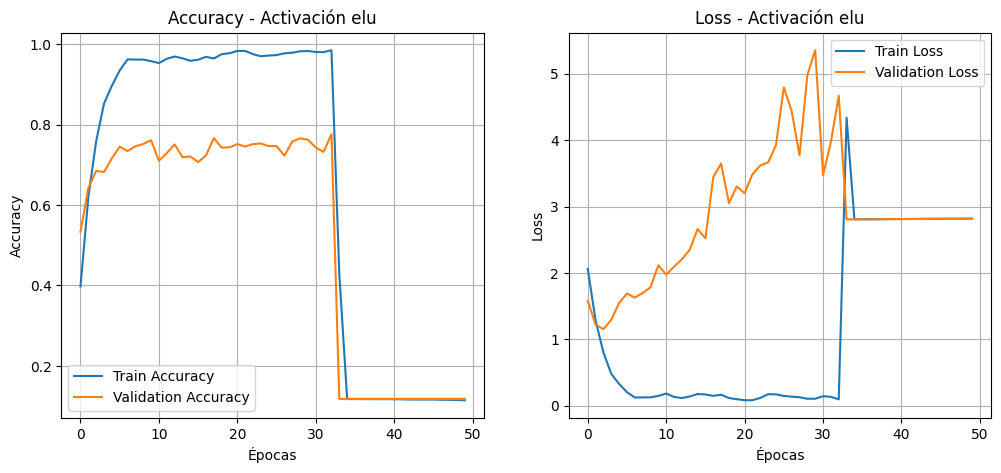

In [55]:
for activacion in ["relu", "tanh", "elu"]:
    modelo_act = crear_cnn_activacion(activacion)
    history_act = entrenar_experimento_base(f"Activación {activacion}", modelo_act)
    graficar_history(history_act, f"Activación {activacion}")

## 7.4 Comparación de optimizadores:

El optimizador define cómo se actualizan los pesos del modelo durante el entrenamiento. Diferentes optimizadores pueden afectar la velocidad de aprendizaje, estabilidad y capacidad de convergencia.

Se comparan los siguientes optimizadores:
- **Adam:** opción robusta y eficiente para problemas de Deep Learning.
- **RMSprop:** se utiliza frecuentemente en redes neuronales.
- **SGD con Momentum:** su uso permite evaluar un método más clásico en las redes pero estable.

El objetivo es identificar qué optimizador entrega mejor rendimiento de validación manteniendo la misma arquitectura base.

In [56]:
def obtener_optimizador_cnn(nombre):
    if nombre == "Adam":
        return keras.optimizers.Adam(learning_rate=0.001)

    elif nombre == "RMSprop":
        return keras.optimizers.RMSprop(learning_rate=0.001)

    elif nombre == "SGD Momentum":
        return keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

    else:
        raise ValueError("Optimizador no reconocido")

In [57]:
def crear_cnn_optimizador(nombre_optimizador="Adam"):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=obtener_optimizador_cnn(nombre_optimizador),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9997
Val Accuracy: 0.8505
Loss: 0.0002
Val Loss: 1.3766


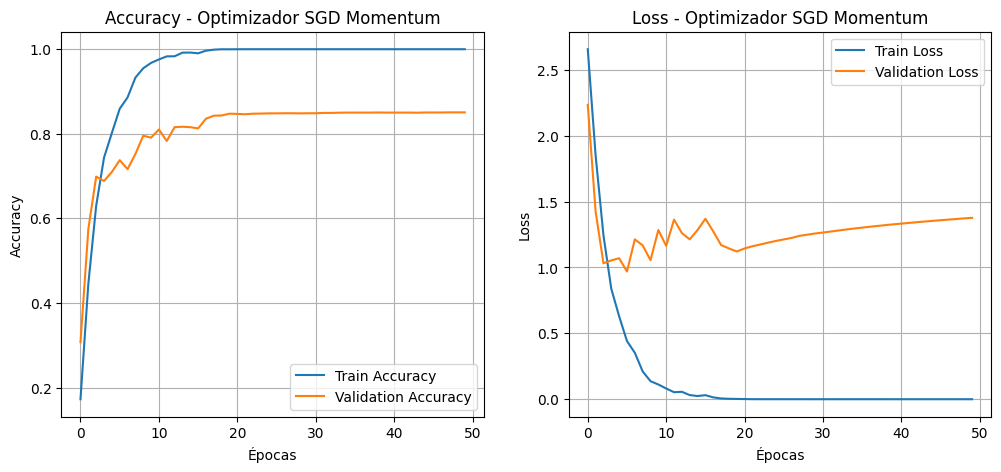

In [58]:
for opt in ["Adam", "RMSprop", "SGD Momentum"]:
    modelo_opt = crear_cnn_optimizador(opt)
    history_opt = entrenar_experimento_base(f"Optimizador {opt}", modelo_opt)
    graficar_history(history_opt, f"Optimizador {opt}")

## 7.5 Función de pérdida:

Para este problema se utiliza `sparse_categorical_crossentropy`, ya que se trata de una clasificación multiclase y las etiquetas están representadas como valores enteros.

La capa de salida utiliza `softmax`, lo que entrega una probabilidad para cada clase. Por esta razón, la función de pérdida debe comparar la distribución de probabilidades predicha con la clase real.

Se mantiene `sparse_categorical_crossentropy` porque es equivalente a `categorical_crossentropy` cuando las etiquetas se trabajan en formato entero, evitando la necesidad de aplicar One Hot Encoding. Por lo tanto, esta elección es coherente con la estructura de los datos y el tipo de problema.

## 7.6 Tabla de resultados de experimentos del modelo base:

### 7.6.1 Comparación de experimentos para seleccionar hiperparámetros

La siguiente tabla resume los experimentos realizados para seleccionar los mejores hiperparámetros del modelo base.

Cada fila corresponde a una prueba específica, como cambios en la profundidad de la arquitectura, función de activación u optimizador. Por lo tanto, esta tabla no representa modelos finales independientes, sino experimentos utilizados para tomar decisiones sobre la configuración del modelo base.

Para la selección se prioriza el accuracy de validación, ya que permite evaluar mejor el rendimiento sobre datos no utilizados directamente durante el entrenamiento.

In [65]:
df_resultados_base = pd.DataFrame(resultados_base)

# Crear una copia para visualización:
df_vista_base = df_resultados_base.copy()

# Clasificar cada experimento según el tipo de prueba realizada:
def clasificar_experimento(nombre):
    if "Base" in nombre:
        return "Arquitectura / Profundidad"
    elif "Activación" in nombre:
        return "Función de activación"
    elif "Optimizador" in nombre:
        return "Optimizador"
    else:
        return "Otro"

df_vista_base["Tipo de prueba"] = df_vista_base["Modelo"].apply(clasificar_experimento)

# Calcular diferencia entre entrenamiento y validación para analizar sobreajuste:
df_vista_base["Gap Accuracy"] = df_vista_base["Train Accuracy"] - df_vista_base["Val Accuracy"]
df_vista_base["Gap Loss"] = df_vista_base["Val Loss"] - df_vista_base["Train Loss"]

# Ordenar por accuracy de validación:
df_vista_base = df_vista_base.sort_values(by="Val Accuracy", ascending=False)

# Reordenar columnas:
df_vista_base = df_vista_base[
    [
        "Tipo de prueba",
        "Modelo",
        "Train Accuracy",
        "Val Accuracy",
        "Gap Accuracy",
        "Train Loss",
        "Val Loss",
        "Gap Loss"
    ]
]

# Estilo de la tabla:
df_vista_base.style \
    .format({
        "Train Accuracy": "{:.2%}",
        "Val Accuracy": "{:.2%}",
        "Gap Accuracy": "{:.2%}",
        "Train Loss": "{:.4f}",
        "Val Loss": "{:.4f}",
        "Gap Loss": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Comparación de experimentos para seleccionar hiperparámetros del modelo base") \
    .highlight_max(subset=["Val Accuracy"], color="#c8e6c9") \
    .highlight_min(subset=["Val Loss"], color="#c8e6c9")

Tipo de prueba,Modelo,Train Accuracy,Val Accuracy,Gap Accuracy,Train Loss,Val Loss,Gap Loss
Función de activación,Activación relu,99.97%,87.50%,12.48%,0.0002,1.1463,1.1461
Arquitectura / Profundidad,Base Profunda con Padding,99.97%,86.42%,13.55%,0.0009,1.2354,1.2345
Optimizador,Optimizador Adam,99.97%,86.08%,13.90%,0.0004,1.2837,1.2832
Optimizador,Optimizador SGD Momentum,99.97%,85.05%,14.92%,0.0002,1.3766,1.3763
Optimizador,Optimizador RMSprop,99.31%,83.94%,15.37%,0.0688,4.6880,4.6192
Arquitectura / Profundidad,Base Media con Padding,99.83%,83.65%,16.18%,0.0060,1.4920,1.4860
Arquitectura / Profundidad,Base Simple,99.97%,78.28%,21.69%,0.0005,2.0720,2.0714
Función de activación,Activación tanh,10.91%,11.82%,-0.91%,2.8242,2.8190,-0.0052
Función de activación,Activación elu,11.48%,11.82%,-0.34%,2.8188,2.8168,-0.0020


### 7.6.2 Análisis de la comparación

A partir de los resultados obtenidos, se observa que la función de activación ReLU obtuvo el mayor accuracy de validación dentro de las pruebas realizadas. También se confirma que Adam fue el optimizador con mejor desempeño entre los evaluados.

Respecto a la arquitectura, la configuración profunda con padding presentó un mejor comportamiento que las arquitecturas más simples, lo que indica que una mayor profundidad permite extraer características visuales más complejas.

Con respecto a `Gap Loss`, corresponde a la diferencia entre la pérdida de validación y la pérdida de entrenamiento. Esta métrica permite analizar si existe diferente enter el error que obtiene el modelo con los datos de entrenamiento y el error que obtiene con datos de validación. En los experimentos realizados, los modelos con ReLU, Adam y arquitectura profunda con padding alcanzaron altos valores de accuracy, pero también presentaron un Gap Loss elevado. Esto indica que, aunque fueron buenos candidatos para construir el modelo base, todavía existía sobreajuste.

Con base en estos resultados, se define el mejor modelo base utilizando una arquitectura profunda con padding, función de activación ReLU, optimizador Adam con learning rate de 0.001 y función de pérdida `sparse_categorical_crossentropy`.

Luego de construir este modelo base, se analizará su sobreajuste para aplicar técnicas de regularización como Dropout, Batch Normalization y Data Augmentation.

In [66]:
df_decisiones_base = pd.DataFrame({
    "Elemento evaluado": [
        "Arquitectura",
        "Función de activación",
        "Optimizador",
        "Learning rate",
        "Función de pérdida",
        "Épocas",
        "Batch size"
    ],
    "Valor seleccionado": [
        "Base profunda con padding",
        "ReLU",
        "Adam",
        "0.001",
        "sparse_categorical_crossentropy",
        "50",
        "64"
    ],
    "Justificación": [
        "Permite extraer características visuales más complejas que una arquitectura simple.",
        "Obtuvo el mejor rendimiento entre las funciones de activación evaluadas.",
        "Mostró mejor desempeño que los optimizadores comparados.",
        "Valor estable y comúnmente utilizado con Adam.",
        "Adecuada para clasificación multiclase con etiquetas enteras.",
        "Permite observar la evolución completa del aprendizaje.",
        "Equilibra estabilidad del entrenamiento y costo computacional."
    ]
})

df_decisiones_base

# Estilo de decisiones:
df_decisiones_base.style \
    .hide(axis="index") \
    .set_caption("Hiperparámetros seleccionados para construir el mejor modelo base")

Elemento evaluado,Valor seleccionado,Justificación
Arquitectura,Base profunda con padding,Permite extraer características visuales más complejas que una arquitectura simple.
Función de activación,ReLU,Obtuvo el mejor rendimiento entre las funciones de activación evaluadas.
Optimizador,Adam,Mostró mejor desempeño que los optimizadores comparados.
Learning rate,0.001,Valor estable y comúnmente utilizado con Adam.
Función de pérdida,sparse_categorical_crossentropy,Adecuada para clasificación multiclase con etiquetas enteras.
Épocas,50,Permite observar la evolución completa del aprendizaje.
Batch size,64,Equilibra estabilidad del entrenamiento y costo computacional.



---
---


# **8. Construcción y evaluación del mejor modelo base.**

A partir de los experimentos realizados en la sección anterior, se definieron los mejores hiperparámetros para construir el modelo base.

En esta etapa no se aplican aún técnicas de regularización como Dropout, Batch Normalization o Data Augmentation. El objetivo es construir un modelo base fuerte, con buena capacidad de aprendizaje, para luego analizar si presenta sobreajuste.

La configuración seleccionada corresponde a una arquitectura profunda con:
| Parámetros | Valores |
| :--- | :---: |
| Epoch| 50 |
| Batch size | 64 |
| Modelo | Base Profunda con Padding |
| Función de Activación | Relu |
| Optimizador | Adam (learning_rate=0.001) |
| Función de Pérdida | sparse_categorical_crossentropy |

Este modelo será utilizado como punto de partida para las siguientes mejoras.

## 8.1 Definición del mejor modelo base:

El mejor modelo base utiliza una arquitectura profunda con varias capas convolucionales. A medida que la red avanza, aumenta la cantidad de filtros, permitiendo aprender características visuales cada vez más complejas.

Se utiliza `padding='same'` para conservar la información espacial durante las convoluciones. Esto evita que el tamaño de los mapas de características se reduzca demasiado rápido antes de aplicar `MaxPooling2D`.

Las capas `MaxPooling2D` reducen la dimensionalidad de los mapas de características, conservando la información más relevante y disminuyendo el costo computacional.

Finalmente, se utiliza una capa densa para la clasificación y una capa de salida con activación `softmax`, ya que el problema corresponde a clasificación multiclase.

In [68]:
def crear_mejor_modelo_base():
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # Primer bloque convolucional
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Segundo bloque convolucional
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Tercer bloque convolucional
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Conversión de mapas de características a vector
        layers.Flatten(),

        # Capa densa para clasificación
        layers.Dense(256, activation="relu"),

        # Capa de salida multiclase
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 8.2 Resumen de la arquitectura:

Se visualiza el resumen del modelo para revisar la estructura de capas, la forma de salida de cada una y la cantidad de parámetros entrenables.

In [69]:
mejor_modelo_base = crear_mejor_modelo_base()
mejor_modelo_base.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,389,042 (9.11 MB)

 Trainable params: 2,389,042 (9.11 MB)

 Non-trainable params: 0 (0.00 B)

## 8.3 Entrenamiento del mejor modelo base:

El modelo se entrena utilizando el conjunto de entrenamiento y se evalúa en cada época con el conjunto de validación.

El objetivo de este entrenamiento es observar si el modelo base logra aprender correctamente y si aparece una diferencia importante entre entrenamiento y validación, lo que podría indicar sobreajuste.

In [72]:
EPOCHS_BASE = 50
BATCH_SIZE_BASE = 64

history_mejor_base = mejor_modelo_base.fit(
    X_train, y_train,
    epochs=EPOCHS_BASE,
    batch_size=BATCH_SIZE_BASE,
    validation_data=(X_val, y_val),
    verbose=0,
    callbacks=[ProgresoEpocas()]
)

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9995
Val Accuracy: 0.8536
Loss: 0.0016
Val Loss: 1.5510


## 8.4 Gráficos de entrenamiento del mejor modelo base:

Se grafican las curvas de accuracy y loss para comparar el comportamiento del modelo en entrenamiento y validación.

Estas curvas permiten identificar si el modelo aprende correctamente y si existe sobreajuste.

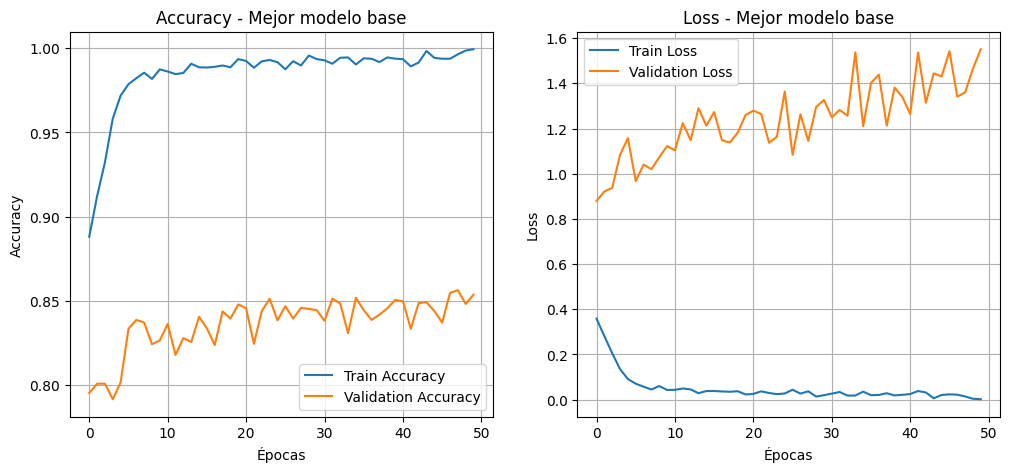

In [75]:
graficar_history(history_mejor_base, "Mejor modelo base")

## 8.5 Resultados del mejor modelo base:

Se calculan las métricas finales del entrenamiento para analizar la diferencia entre entrenamiento y validación.

In [76]:
train_acc_base = history_mejor_base.history["accuracy"][-1]
val_acc_base = history_mejor_base.history["val_accuracy"][-1]
train_loss_base = history_mejor_base.history["loss"][-1]
val_loss_base = history_mejor_base.history["val_loss"][-1]

gap_acc_base = train_acc_base - val_acc_base
gap_loss_base = val_loss_base - train_loss_base

df_resultado_mejor_base = pd.DataFrame({
    "Métrica": [
        "Train Accuracy",
        "Val Accuracy",
        "Gap Accuracy",
        "Train Loss",
        "Val Loss",
        "Gap Loss"
    ],
    "Valor": [
        train_acc_base,
        val_acc_base,
        gap_acc_base,
        train_loss_base,
        val_loss_base,
        gap_loss_base
    ]
})

df_resultado_mejor_base

,Métrica,Valor
0,Train Accuracy,0.999473
1,Val Accuracy,0.853646
2,Gap Accuracy,0.145828
3,Train Loss,0.001614
4,Val Loss,1.550998
5,Gap Loss,1.549385


## 8.6 Diagnóstico de sobreajuste:

El mejor modelo base permite alcanzar una alta precisión en entrenamiento, lo que indica que la arquitectura tiene buena capacidad de aprendizaje.

Sin embargo, si el accuracy de entrenamiento es considerablemente mayor que el accuracy de validación, y la pérdida de validación es mucho mayor que la pérdida de entrenamiento, se puede identificar presencia de sobreajuste.

Este diagnóstico es importante porque justifica la siguiente etapa del trabajo: aplicar técnicas de regularización para mejorar la generalización del modelo.


## 8.7 Guardar el mejor modelo base para usarlo después:

In [77]:
# Guardamos el mejor modelo base y su historial para utilizarlo como referencia:

modelo_base_final = mejor_modelo_base
history_base_final = history_mejor_base

---
---

# **9. Regularización y mejora del mejor modelo base.**

En la sección anterior se construyó el mejor modelo base utilizando los hiperparámetros seleccionados a partir de los experimentos previos: arquitectura profunda con padding, función de activación ReLU, optimizador Adam y función de pérdida `sparse_categorical_crossentropy`.

Este modelo logró una alta capacidad de aprendizaje, pero también presentó señales de sobreajuste. Esto se observó en la diferencia entre el accuracy de entrenamiento y validación, además de una pérdida de validación mayor que la pérdida de entrenamiento.

Por esta razón, en esta sección se aplicarán técnicas orientadas a reducir el sobreajuste y mejorar la generalización del modelo:

- Dropout.
- Batch Normalization + Dropout.
- Data Augmentation.

Estas técnicas serán aplicadas sobre la arquitectura base seleccionada, manteniendo los hiperparámetros principales constantes para realizar una comparación justa.

## 9.1 Funciones auxiliares para entrenar y comparar:

Para mantener el notebook ordenado, se definen funciones auxiliares que permiten entrenar los modelos regularizados, guardar sus resultados y graficar sus curvas de accuracy y loss.

En esta etapa se compararán solo los modelos que incorporan técnicas contra el sobreajuste. El mejor modelo base ya fue utilizado en la sección anterior para evidenciar el problema de overfitting.

In [78]:
# Hiperparámetros comunes para los modelos regularizados:
EPOCHS_REG = 50
BATCH_SIZE_REG = 64

# Diccionarios para guardar modelos e historiales:
modelos_regularizados = {}
histories_regularizados = {}

# Lista para guardar resultados comparativos:
resultados_regularizados = []

### Función para entrenar modelo:

In [79]:
def entrenar_modelo_regularizado(nombre_modelo, modelo):
    print(f"\nEntrenando: {nombre_modelo}")

    history = modelo.fit(
        X_train, y_train,
        epochs=EPOCHS_REG,
        batch_size=BATCH_SIZE_REG,
        validation_data=(X_val, y_val),
        verbose=0,
        callbacks=[ProgresoEpocas()]
    )

    modelos_regularizados[nombre_modelo] = modelo
    histories_regularizados[nombre_modelo] = history

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_loss = history.history["val_loss"][-1]

    resultados_regularizados.append({
        "Modelo": nombre_modelo,
        "Train Accuracy": train_acc,
        "Val Accuracy": val_acc,
        "Gap Accuracy": train_acc - val_acc,
        "Train Loss": train_loss,
        "Val Loss": val_loss,
        "Gap Loss": val_loss - train_loss
    })

    return history

### Función para graficar modelo:

In [80]:
def graficar_entrenamiento_regularizado(history, titulo):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - {titulo}")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - {titulo}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

## 9.2 Mejor modelo base + Dropout:

La primera técnica aplicada para reducir el sobreajuste es Dropout.

Dropout desactiva aleatoriamente una proporción de neuronas durante el entrenamiento. Esto evita que el modelo dependa demasiado de conexiones específicas y ayuda a disminuir la memorización del conjunto de entrenamiento.

- Se aplica Dropout en la parte densa del modelo, ya que después de la capa `Flatten` se genera una gran cantidad de conexiones. Esta zona del modelo suele ser propensa al sobreajuste, especialmente cuando la red ya aprendió muy bien las imágenes de entrenamiento.
- Se aplica un Dropout de 0.5 ya que el modelo presentó un sobreajuste alto. El valor 0.5 es común en capas densas cuando existe sobreajuste considerable. Por lo que se indica que durante el entrenamiento desactive aleatoriamente el 50% de las neuronas para luego aprender representaciones más generales y menos dependientes de conexiones específicas.

El objetivo de esta prueba es observar si Dropout reduce la diferencia entre entrenamiento y validación.

In [81]:
# Creación de modelo con DropOut:
def crear_modelo_dropout():
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # Primer bloque convolucional:
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Segundo bloque convolucional:
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Tercer bloque convolucional:
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        # Dropout se agrega a la arquitectura luego de aplicar las capas densas,
        # para que así desactive neuronas aleatoriamente:
        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [85]:
modelo_dropout = crear_modelo_dropout()
modelo_dropout.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_68 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,389,042 (9.11 MB)

 Trainable params: 2,389,042 (9.11 MB)

 Non-trainable params: 0 (0.00 B)

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9863
Val Accuracy: 0.9050
Loss: 0.0426
Val Loss: 0.6884


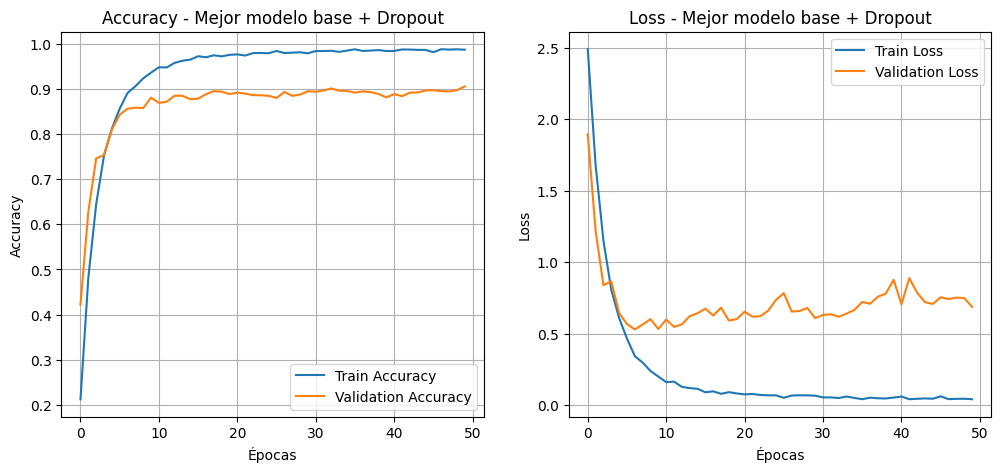

In [82]:
history_dropout = entrenar_modelo_regularizado(
    "Mejor modelo base + Dropout",
    modelo_dropout
)

graficar_entrenamiento_regularizado(
    history_dropout,
    "Mejor modelo base + Dropout"
)

En este modelo se analiza si Dropout logra reducir el sobreajuste observado en el mejor modelo base.

## 9.3 Mejor modelo base + Batch Normalization y Dropout:

En esta variante se incorpora Batch Normalization junto con Dropout.

- Batch Normalization normaliza las activaciones internas de la red durante el entrenamiento. Esto ayuda a estabilizar el aprendizaje, especialmente en redes más profundas, donde los valores que circulan entre capas pueden variar demasiado.

- Se mantiene Dropout(0.5) en la parte densa para reducir el sobreajuste. La combinación de Batch Normalization y Dropout busca mejorar tanto la estabilidad del entrenamiento como la capacidad de generalización del modelo.

In [83]:
def crear_modelo_batchnorm_dropout():
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # Primer bloque convolucional:
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        # Segundo bloque convolucional:
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        # Tercer bloque convolucional:
        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [86]:
modelo_batchnorm_dropout = crear_modelo_batchnorm_dropout()
modelo_batchnorm_dropout.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_74 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 8192)           │             

 Total params: 2,391,858 (9.12 MB)

 Trainable params: 2,390,450 (9.12 MB)

 Non-trainable params: 1,408 (5.50 KB)

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9956
Val Accuracy: 0.9010
Loss: 0.0137
Val Loss: 0.5063


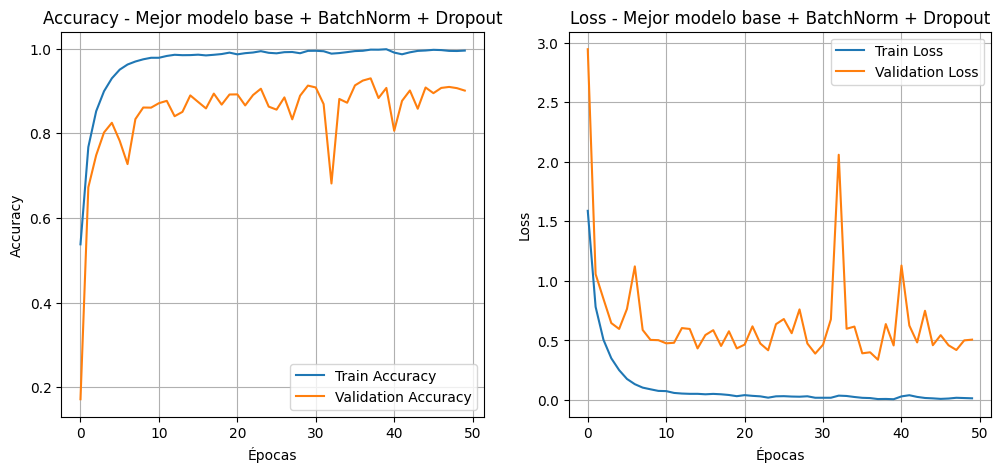

In [84]:
history_batchnorm_dropout = entrenar_modelo_regularizado(
    "Mejor modelo base + BatchNorm + Dropout",
    modelo_batchnorm_dropout
)

graficar_entrenamiento_regularizado(
    history_batchnorm_dropout,
    "Mejor modelo base + BatchNorm + Dropout"
)

Este modelo permite evaluar si la normalización interna de la red mejora la estabilidad del entrenamiento.

Batch Normalization puede ayudar a que el modelo aprenda de forma más ordenada, mientras que Dropout reduce la dependencia excesiva entre neuronas.

## 9.4 Mejor modelo base + Data Augmentation:

En esta variante se incorpora Data Augmentation como técnica para mejorar la generalización.

- Data Augmentation genera variaciones artificiales de las imágenes de entrenamiento, como rotaciones, desplazamientos, zoom y volteos horizontales. Esto permite que el modelo vea imágenes ligeramente distintas durante el entrenamiento.
- Se mantiene Dropout(0.5) en la parte densa para reducir el sobreajuste.

Esta técnica se aplica porque el mejor modelo base presentó sobreajuste. Al aumentar la variabilidad de los datos, el modelo se ve obligado a aprender características más generales de los personajes, en lugar de memorizar imágenes específicas.

In [87]:
# Creación de data augmentation:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

In [88]:
def crear_modelo_data_augmentation():
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # Aumento de datos aplicado solo durante entrenamiento:
        data_augmentation,

        # Primer bloque convolucional:
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Segundo bloque convolucional:
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # Tercer bloque convolucional:
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [89]:
modelo_data_aug = crear_modelo_data_augmentation()
modelo_data_aug.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_15 (Sequential)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,389,042 (9.11 MB)

 Trainable params: 2,389,042 (9.11 MB)

 Non-trainable params: 0 (0.00 B)

Progreso del entrenamiento: 50/50 épocas (100.0%)
Accuracy: 0.9555
Val Accuracy: 0.9426
Loss: 0.1508
Val Loss: 0.2597


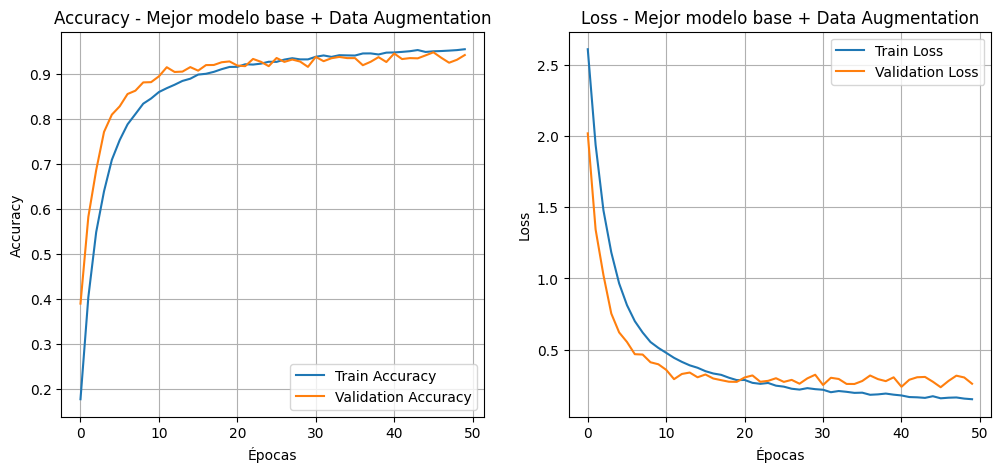

In [90]:
history_data_aug = entrenar_modelo_regularizado(
    "Mejor modelo base + Data Augmentation",
    modelo_data_aug
)

graficar_entrenamiento_regularizado(
    history_data_aug,
    "Mejor modelo base + Data Augmentation"
)

El modelo con Data Augmentation permite evaluar si aumentar artificialmente la variabilidad de las imágenes ayuda a mejorar la generalización.

Si la validación se mantiene más estable o disminuye la diferencia con el entrenamiento, significa que el modelo está aprendiendo patrones más generales y no solo memorizando imágenes específicas.

Es normal que el accuracy de entrenamiento pueda ser menor que en el modelo base, ya que el modelo recibe imágenes transformadas durante el entrenamiento.

## 9.5 Comparación de modelos regularizados:

Una vez entrenados los modelos regularizados, se comparan sus resultados para analizar cuál técnica logró mejorar mejor la generalización.

Para esta comparación se consideran:

- Accuracy de validación.
- Pérdida de validación.
- Diferencia entre accuracy de entrenamiento y validación.
- Diferencia entre pérdida de entrenamiento y validación.

Un buen modelo no necesariamente es el que obtiene mayor accuracy de entrenamiento, sino aquel que mantiene buen rendimiento en validación y reduce las señales de sobreajuste.

In [91]:
df_resultados_regularizados = pd.DataFrame(resultados_regularizados)

df_resultados_regularizados = df_resultados_regularizados.sort_values(
    by="Val Accuracy",
    ascending=False
)

df_resultados_regularizados.style \
    .format({
        "Train Accuracy": "{:.2%}",
        "Val Accuracy": "{:.2%}",
        "Gap Accuracy": "{:.2%}",
        "Train Loss": "{:.4f}",
        "Val Loss": "{:.4f}",
        "Gap Loss": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Comparación de modelos regularizados") \
    .highlight_max(subset=["Val Accuracy"], color="#c8e6c9") \
    .highlight_min(subset=["Val Loss"], color="#c8e6c9") \
    .highlight_min(subset=["Gap Accuracy"], color="#fff9c4")

Modelo,Train Accuracy,Val Accuracy,Gap Accuracy,Train Loss,Val Loss,Gap Loss
Mejor modelo base + Data Augmentation,95.55%,94.26%,1.29%,0.1508,0.2597,0.1089
Mejor modelo base + Dropout,98.63%,90.50%,8.13%,0.0426,0.6884,0.6458
Mejor modelo base + BatchNorm + Dropout,99.56%,90.10%,9.46%,0.0137,0.5063,0.4926


In [92]:
# Selección del mejor modelo regularizado según los resultados obtenidos:

mejor_modelo_nombre = "Mejor modelo base + Data Augmentation"

model_final = modelos_regularizados[mejor_modelo_nombre]
history_final = histories_regularizados[mejor_modelo_nombre]

print("Modelo regularizado seleccionado:", mejor_modelo_nombre)

Modelo regularizado seleccionado: Mejor modelo base + Data Augmentation


## Análisis de los modelos regularizados:

La comparación de modelos regularizados muestra que la variante con **Data Augmentation** obtuvo el mejor rendimiento general en validación.

El modelo **Mejor modelo base + Data Augmentation** alcanzó un `Val Accuracy` de 94.26%, superando a los modelos con Dropout y Batch Normalization + Dropout. Además, presentó el menor `Gap Accuracy`, con una diferencia de solo 1.29% entre entrenamiento y validación.

Esto indica que Data Augmentation logró reducir considerablemente el sobreajuste, ya que el modelo mantiene un rendimiento alto en validación sin depender excesivamente del conjunto de entrenamiento.

En comparación, el modelo con Dropout obtuvo un `Val Accuracy` de 90.50% y un `Gap Accuracy` de 8.13%, mientras que el modelo con Batch Normalization + Dropout obtuvo un `Val Accuracy` de 90.10% y un `Gap Accuracy` de 9.46%. Aunque ambos modelos mejoraron respecto al sobreajuste inicial, todavía presentan una diferencia mayor entre entrenamiento y validación.

También se observa que Data Augmentation obtuvo la menor pérdida de validación (`Val Loss` = 0.2597) y el menor `Gap Loss`, lo que refuerza que este modelo presenta un comportamiento más estable y una mejor capacidad de generalización.

Por esta razón, se selecciona **Mejor modelo base + Data Augmentation** como el modelo regularizado con mejor desempeño.

---
---

# **10. Comparación entre modelo base y modelo final.**

En esta sección se compara el mejor modelo base con el modelo final regularizado seleccionado en la etapa anterior.

El objetivo es verificar si la técnica aplicada logró reducir el sobreajuste observado inicialmente. Para esto se comparan métricas como accuracy, loss y la diferencia entre entrenamiento y validación.

El modelo final seleccionado corresponde a **Mejor modelo base + Data Augmentation**, ya que obtuvo el mejor rendimiento en validación y la menor diferencia entre entrenamiento y validación.

In [94]:
# Métricas del mejor modelo base:
base_train_acc = history_mejor_base.history["accuracy"][-1]
base_val_acc = history_mejor_base.history["val_accuracy"][-1]
base_train_loss = history_mejor_base.history["loss"][-1]
base_val_loss = history_mejor_base.history["val_loss"][-1]

# Métricas del modelo final regularizado:
final_train_acc = history_final.history["accuracy"][-1]
final_val_acc = history_final.history["val_accuracy"][-1]
final_train_loss = history_final.history["loss"][-1]
final_val_loss = history_final.history["val_loss"][-1]

# Tabla comparativa:
df_comparacion_base_final = pd.DataFrame({
    "Modelo": [
        "Mejor modelo base",
        "Modelo final regularizado"
    ],
    "Train Accuracy": [
        base_train_acc,
        final_train_acc
    ],
    "Val Accuracy": [
        base_val_acc,
        final_val_acc
    ],
    "Gap Accuracy": [
        base_train_acc - base_val_acc,
        final_train_acc - final_val_acc
    ],
    "Train Loss": [
        base_train_loss,
        final_train_loss
    ],
    "Val Loss": [
        base_val_loss,
        final_val_loss
    ],
    "Gap Loss": [
        base_val_loss - base_train_loss,
        final_val_loss - final_train_loss
    ]
})

df_comparacion_base_final.style \
    .format({
        "Train Accuracy": "{:.2%}",
        "Val Accuracy": "{:.2%}",
        "Gap Accuracy": "{:.2%}",
        "Train Loss": "{:.4f}",
        "Val Loss": "{:.4f}",
        "Gap Loss": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Comparación entre mejor modelo base y modelo final regularizado") \
    .highlight_max(subset=["Val Accuracy"], color="#c8e6c9") \
    .highlight_min(subset=["Gap Accuracy"], color="#fff9c4") \
    .highlight_min(subset=["Val Loss"], color="#c8e6c9")

Modelo,Train Accuracy,Val Accuracy,Gap Accuracy,Train Loss,Val Loss,Gap Loss
Mejor modelo base,99.95%,85.36%,14.58%,0.0016,1.5510,1.5494
Modelo final regularizado,95.55%,94.26%,1.29%,0.1508,0.2597,0.1089


## Análisis comparativo:

Al comparar el mejor modelo base con el modelo final regularizado, se observa que la aplicación de Data Augmentation permitió mejorar la generalización del modelo.

El mejor modelo base presentaba una diferencia considerable entre el accuracy de entrenamiento y el accuracy de validación, lo que evidenciaba sobreajuste. En cambio, el modelo final regularizado mantiene un accuracy de validación más alto y una diferencia mucho menor entre entrenamiento y validación.

Además, la pérdida de validación disminuye en el modelo final, lo que indica que el error sobre datos no vistos se redujo. Esto demuestra que Data Augmentation ayudó a que el modelo aprendiera patrones más generales, en lugar de memorizar imágenes específicas del conjunto de entrenamiento.

Por lo tanto, el modelo final regularizado presenta un mejor equilibrio entre precisión y generalización, cumpliendo el objetivo de reducir el sobreajuste detectado en el modelo base.

---
---

# **11. Evaluación final en el conjunto de prueba.**

Aquí es donde utilizaremos las siguientes variables guardadas anteriormente:
- model_final
- history_final
- mejor_modelo_nombre

Y lo evaluaremos con:
- X_test
- y_test

En esta sección se calcularán métricas como:
- accuracy.
- precision.
- recall.
- F1-score.

Además, se utilizará una matriz de confusión y ejemplos visuales de predicción para analizar el comportamiento del modelo.

## 11.1 Evaluación general del modelo final:

Primero se evalúa el modelo final utilizando la función `evaluate`, la cual entrega la pérdida y el accuracy sobre el conjunto de prueba.

Estas métricas permiten obtener una primera visión del rendimiento del modelo sobre datos completamente nuevos.

In [95]:
# Evaluación general del modelo final en el conjunto de prueba:
test_loss, test_accuracy = model_final.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9753 - loss: 0.1027
Test Loss: 0.1027
Test Accuracy: 0.9753


## 11.2 Predicciones del modelo final:

La capa de salida del modelo utiliza `softmax`, por lo que entrega una probabilidad para cada clase.

Para obtener la clase predicha, se selecciona la clase con mayor probabilidad mediante `argmax`.

In [96]:
# Predicciones del modelo final:
y_pred_probs = model_final.predict(X_test)

# Convertimos las probabilidades en clases predichas:
y_pred = np.argmax(y_pred_probs, axis=1)

# Etiquetas reales:
y_true = y_test

print("Primeras predicciones:", y_pred[:20])
print("Etiquetas reales:", y_true[:20])

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Primeras predicciones: [10 15  6  0 13  8  9 15  0 17 12 12  1 17 13 10 17  6  5 11]
Etiquetas reales: [10 15  6  0 13  8  9 15  0 17 12 12  1 17 13 10 17  6  5 11]


## 11.3 Métricas finales:

Para evaluar el rendimiento del modelo se utilizan distintas métricas de clasificación.

- **Accuracy:** indica el porcentaje total de imágenes clasificadas correctamente.
- **Precision:** mide qué tan confiables son las predicciones del modelo.
- **Recall:** indica qué proporción de ejemplos reales de cada clase fueron identificados correctamente.
- **F1-score:** combina precision y recall en una sola métrica equilibrada.

Se utiliza el promedio macro porque el problema tiene múltiples clases y se busca evaluar todas las clases con el mismo peso.

In [102]:
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro")
recall_macro = recall_score(y_true, y_pred, average="macro")
f1_macro = f1_score(y_true, y_pred, average="macro")

df_metricas_finales = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1-score Macro"
    ],
    "Valor": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro
    ]
})

df_metricas_finales.style \
    .format({"Valor": "{:.2%}"}) \
    .hide(axis="index") \
    .set_caption("Métricas finales del modelo en el conjunto de prueba")

Métrica,Valor
Accuracy,97.53%
Precision Macro,97.63%
Recall Macro,97.53%
F1-score Macro,97.54%


### Análisis de métricas finales

El modelo final obtuvo un accuracy de 97.53% en el conjunto de prueba, lo que indica que clasificó correctamente la gran mayoría de las imágenes evaluadas.

Además, alcanzó una precision macro de 97.63%, recall macro de 97.53% y F1-score macro de 97.54%. La cercanía entre estas métricas indica que el modelo mantiene un desempeño equilibrado entre las distintas clases.

El F1-score macro es especialmente relevante porque considera todas las clases con el mismo peso, evitando que el resultado dependa únicamente de las clases con mejor rendimiento.

En general, estos resultados muestran que el modelo final logró una alta capacidad de generalización sobre imágenes no vistas.

## 11.4 Reporte de clasificación por clase:

El reporte de clasificación permite analizar el rendimiento del modelo para cada personaje de manera individual.

Esto ayuda a identificar qué clases fueron reconocidas con mayor facilidad y cuáles presentaron más dificultad para el modelo.

In [101]:
reporte = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(reporte)

                          precision    recall  f1-score   support

  abraham_grampa_simpson     1.0000    0.9792    0.9895        48
  apu_nahasapeemapetilon     1.0000    0.9800    0.9899        50
            bart_simpson     0.9800    0.9800    0.9800        50
charles_montgomery_burns     0.9200    0.9583    0.9388        48
            chief_wiggum     0.9074    0.9800    0.9423        50
          comic_book_guy     1.0000    0.9388    0.9684        49
          edna_krabappel     1.0000    0.9200    0.9583        50
           homer_simpson     0.9800    0.9800    0.9800        50
           kent_brockman     1.0000    1.0000    1.0000        50
        krusty_the_clown     1.0000    1.0000    1.0000        50
            lisa_simpson     1.0000    0.9800    0.9899        50
           marge_simpson     1.0000    0.9800    0.9899        50
     milhouse_van_houten     0.9600    0.9796    0.9697        49
             moe_szyslak     0.9245    0.9800    0.9515        50
         

## 11.5 Matriz de confusión:

La matriz de confusión permite comparar las clases reales con las clases predichas por el modelo.

La diagonal principal representa las predicciones correctas. Los valores fuera de la diagonal representan errores de clasificación.

Esta herramienta permite identificar visualmente qué personajes fueron clasificados correctamente y cuáles fueron confundidos entre sí.

<Figure size 1200x1000 with 0 Axes>

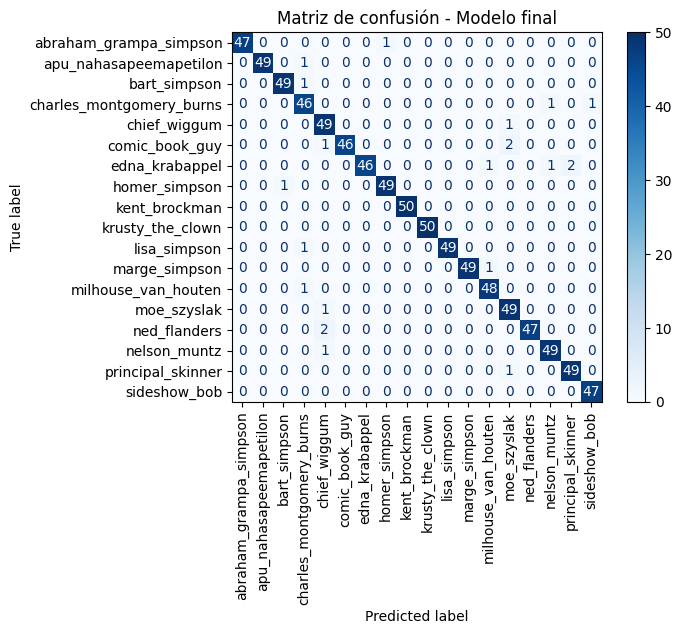

In [104]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión - Modelo final")
plt.show()

## Análisis de la matriz de confusión:

La matriz de confusión muestra un resultado muy favorable para el modelo final. La mayoría de los valores se concentran en la diagonal principal, lo que indica que el modelo clasificó correctamente la mayor parte de las imágenes de cada personaje.

En total, el modelo acertó 868 imágenes de 890, alcanzando un accuracy aproximado de 97.53% en el conjunto de prueba.

Los errores fuera de la diagonal son bajos y aislados. Las principales confusiones se presentaron entre `ned_flanders` y `chief_wiggum`, `comic_book_guy` y `moe_szyslak`, y `edna_krabappel` y `principal_skinner`, con 2 errores en cada caso.

Estas confusiones pueden explicarse por similitudes visuales entre personajes, colores similares, posturas, expresiones o fondos complejos en algunas imágenes. Sin embargo, la cantidad de errores es baja en comparación con el total de imágenes evaluadas.

En general, la matriz de confusión respalda el buen desempeño del modelo final, demostrando que logra diferenciar correctamente la mayoría de los personajes.

## 11.6 Errores más frecuentes:

Además de la matriz de confusión, se construye una tabla con las confusiones más frecuentes del modelo.

Esto permite identificar de manera directa qué personajes fueron confundidos con mayor frecuencia.

In [106]:
# Crear tabla de errores más frecuentes:
errores = []

for real in range(len(class_names)):
    for pred in range(len(class_names)):
        if real != pred and cm[real, pred] > 0:
            errores.append({
                "Clase real": class_names[real],
                "Clase predicha": class_names[pred],
                "Cantidad de errores": cm[real, pred]
            })

df_errores = pd.DataFrame(errores)

df_errores = df_errores.sort_values(
    by="Cantidad de errores",
    ascending=False
)

df_errores.head(10)

,Clase real,Clase predicha,Cantidad de errores
16,ned_flanders,chief_wiggum,2
7,comic_book_guy,moe_szyslak,2
10,edna_krabappel,principal_skinner,2
2,bart_simpson,charles_montgomery_burns,1
1,apu_nahasapeemapetilon,charles_montgomery_burns,1
0,abraham_grampa_simpson,homer_simpson,1
3,charles_montgomery_burns,nelson_muntz,1
6,comic_book_guy,chief_wiggum,1
5,chief_wiggum,moe_szyslak,1
8,edna_krabappel,milhouse_van_houten,1


# **12. Visualización de predicciones del modelo final.**

Finalmente, se visualizan ejemplos de predicciones realizadas por el modelo final.

En cada imagen se muestra la clase real, la clase predicha y la confianza del modelo. Las predicciones correctas se muestran en color verde, mientras que los errores se muestran en color rojo.

Este análisis visual permite interpretar de manera más concreta el comportamiento del modelo.

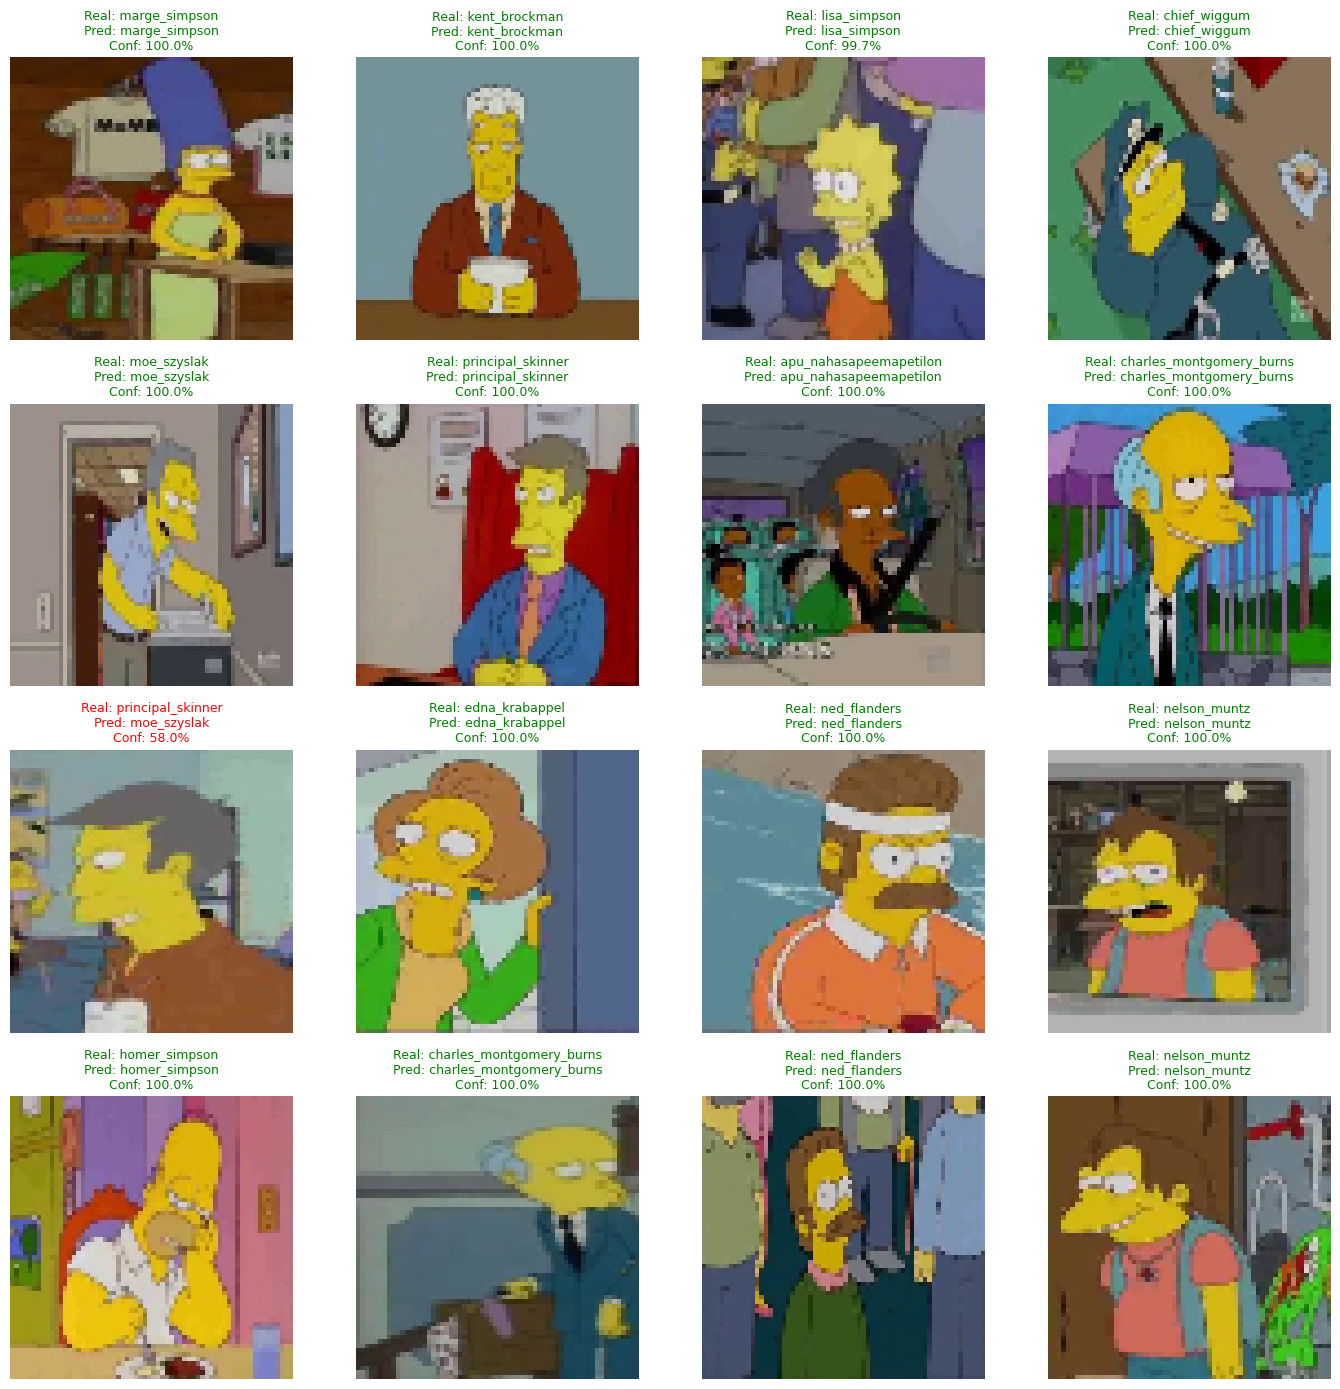

In [107]:
# Visualización de predicciones aleatorias:

filas = 4
columnas = 4

plt.figure(figsize=(14, 14))

for i in range(filas * columnas):
    idx = np.random.randint(0, len(X_test))

    img = X_test[idx]

    # Conversión de fotos de BGR a RGB para demostración:
    img_rgb = img[..., ::-1]

    clase_real = y_test[idx]
    clase_predicha = y_pred[idx]

    nombre_real = class_names[clase_real]
    nombre_predicho = class_names[clase_predicha]

    confianza = np.max(y_pred_probs[idx]) * 100

    color = "green" if clase_real == clase_predicha else "red"

    plt.subplot(filas, columnas, i + 1)
    plt.imshow(img_rgb)
    plt.title(
        f"Real: {nombre_real}\nPred: {nombre_predicho}\nConf: {confianza:.1f}%",
        color=color,
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 12.1 Visualización solo de errores:

Cantidad de errores encontrados: 22


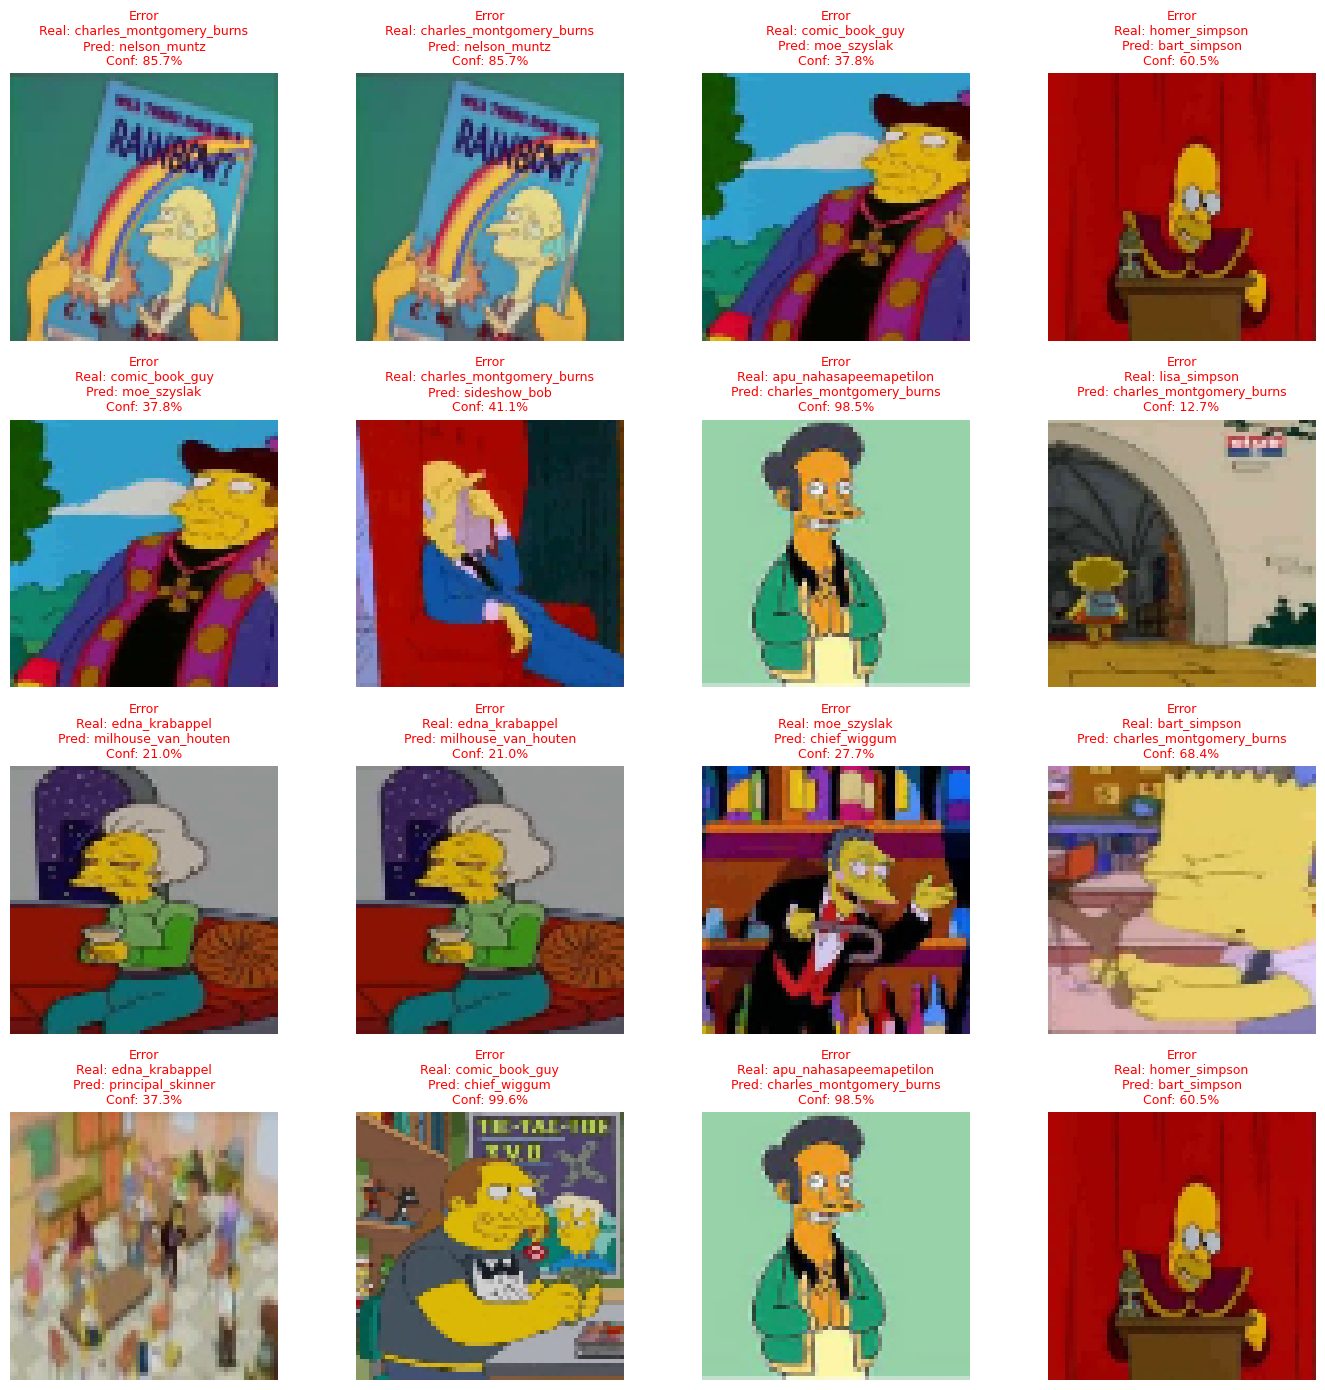

In [108]:
# Mostrar solo ejemplos donde el modelo se equivocó:

errores_idx = np.where(y_pred != y_test)[0]

print("Cantidad de errores encontrados:", len(errores_idx))

filas = 4
columnas = 4

plt.figure(figsize=(14, 14))

for i in range(min(filas * columnas, len(errores_idx))):
    idx = np.random.choice(errores_idx)

    img = X_test[idx]
    img_rgb = img[..., ::-1]

    clase_real = y_test[idx]
    clase_predicha = y_pred[idx]

    nombre_real = class_names[clase_real]
    nombre_predicho = class_names[clase_predicha]

    confianza = np.max(y_pred_probs[idx]) * 100

    plt.subplot(filas, columnas, i + 1)
    plt.imshow(img_rgb)
    plt.title(
        f"Error\nReal: {nombre_real}\nPred: {nombre_predicho}\nConf: {confianza:.1f}%",
        color="red",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Análisis visual de predicciones:

La visualización de predicciones permite observar ejemplos concretos del comportamiento del modelo.

En los aciertos, el modelo logra reconocer correctamente características visuales distintivas de los personajes. En los errores, las confusiones pueden deberse a similitudes visuales, fondos complejos, posturas poco claras o variaciones dentro de las imágenes.

Este análisis complementa las métricas numéricas, ya que permite interpretar visualmente los casos en que el modelo acierta y aquellos donde presenta dificultades.

---
---

## 13. Conclusiones

En este trabajo se implementó una Red Neuronal Convolucional para clasificar imágenes de personajes de Los Simpsons. El desarrollo se realizó siguiendo un proceso experimental, comenzando con la búsqueda de un modelo base con buen rendimiento y posteriormente aplicando técnicas para reducir el sobreajuste.

Primero se probaron distintas configuraciones del modelo base, modificando elementos como la profundidad de la arquitectura, la función de activación, el optimizador y la función de pérdida. A partir de estos experimentos se seleccionó una arquitectura profunda con padding, función de activación ReLU, optimizador Adam con learning rate de 0.001 y función de pérdida `sparse_categorical_crossentropy`.

El modelo base logró una alta precisión en entrenamiento, pero presentó señales de sobreajuste, ya que existía una diferencia importante entre el rendimiento de entrenamiento y validación. Por esta razón, se aplicaron técnicas de regularización y mejora de generalización, como Dropout, Batch Normalization y Data Augmentation.

El modelo final seleccionado corresponde a una CNN profunda personalizada de estilo VGG-like, con padding, Data Augmentation y Dropout. Se considera VGG-like porque utiliza bloques secuenciales de convoluciones 3x3, aumento progresivo de filtros y capas MaxPooling2D. No corresponde directamente a ResNet, ya que no utiliza conexiones residuales, ni a Inception, ya que no utiliza ramas paralelas.

El modelo final alcanzó un accuracy aproximado de 97.53% en el conjunto de prueba, clasificando correctamente 868 imágenes de un total de 890. Este resultado demuestra que la arquitectura fue capaz de aprender características visuales relevantes de los personajes, como formas, colores, rasgos faciales y patrones distintivos.

La matriz de confusión mostró que la mayoría de las predicciones correctas se concentran en la diagonal principal, con errores aislados entre algunas clases. Las confusiones detectadas pueden explicarse por similitudes visuales entre ciertos personajes, posturas, fondos o variaciones en las imágenes.

En conclusión, el modelo CNN final logró un rendimiento alto y equilibrado para la clasificación de personajes de Los Simpsons. El proceso de comparación de arquitecturas e hiperparámetros permitió justificar las decisiones tomadas, mientras que las técnicas de regularización ayudaron a mejorar la generalización del modelo frente a datos no vistos.

## 13.1 Resumen de arquitectura:

La red convolucional creada cuenta con las siguientes características:
- Usa varias capas convolucionales seguidas.
- Usa filtros pequeños de 3x3.
- Aumenta progresivamente los filtros: 32 - 64 - 128.
- Usa MaxPooling2D para reducir el tamaño espacial de las imágenes.
- Usa capas densas para clasificar.

Parámetros finales del modelo creado:

| Parámetros | Valores |
| :--- | :---: |
| **Epoch**| 50 |
| **Batch size** | 64 |
| **Filtros convolucionales** | 32, 64 y 128 |
| **Tamaño de kernel**| 3x3 |
| **Modelo** | Base Profunda con Padding y Data Augmentation |
| **Regularización** | Dropout |
| **Función de Activación** | Relu |
| **Optimizador** | Adam  |
| **Learning rate** | 0.001 |
| **Función de Pérdida** | sparse_categorical_crossentropy |
| **Métrica principal** | accuracy |




